In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML
from keras.preprocessing.image import ImageDataGenerator


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
IMAGE_SIZE = 256
CHANNELS = 3

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/A simple model.v1i.folder/Data/train',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse'
)

Found 878 images belonging to 4 classes.


In [ ]:
for image_batch, label_batch in train_generator:
    print(image_batch[0])
    break

[[[0.545279   0.5529412  0.6       ]
  [0.5530261  0.5528564  0.6       ]
  [0.5567836  0.54901963 0.59992087]
  ...
  [0.09671821 0.09279665 0.09671821]
  [0.09755968 0.09363811 0.09755968]
  [0.0981297  0.09420813 0.0981297 ]]

 [[0.5448583  0.5527014  0.5996404 ]
  [0.55269015 0.5529412  0.6       ]
  [0.55673164 0.5491508  0.6       ]
  ...
  [0.1016249  0.09770332 0.1016249 ]
  [0.10183526 0.09791369 0.10183526]
  [0.10196079 0.09812406 0.10196079]]

 [[0.5444376  0.5522807  0.5990093 ]
  [0.5522694  0.5529412  0.6       ]
  [0.55652124 0.54936117 0.6       ]
  ...
  [0.10196079 0.10161925 0.10196079]
  [0.10196079 0.10182961 0.10196079]
  [0.10211916 0.10203998 0.10211916]]

 ...

 [[0.2784314  0.21960786 0.1845513 ]
  [0.27751315 0.22026375 0.18431373]
  [0.27604058 0.22131556 0.18431373]
  ...
  [0.3118532  0.27911448 0.26803285]
  [0.33266154 0.28425914 0.28067347]
  [0.32449946 0.2620846  0.2620846 ]]

 [[0.25157425 0.23879154 0.18431373]
  [0.2485953  0.23833698 0.18255629]


In [ ]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

validation_generator = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/A simple model.v1i.folder/Data/val',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse'
)

Found 181 images belonging to 4 classes.


In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/A simple model.v1i.folder/Data/test',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse'
)

Found 191 images belonging to 4 classes.


In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 4

model = models.Sequential([
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 64)        0

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=20,
    batch_size=32,
    validation_data=validation_generator,
    validation_steps=6,
    verbose=1,
    epochs=100

)

Epoch 1/100
20/20 [==============================] - 256s 12s/step - loss: 1.3262 - accuracy: 0.3859 - val_loss: 1.3674 - val_accuracy: 0.3315
Epoch 2/100
20/20 [==============================] - 39s 2s/step - loss: 1.2412 - accuracy: 0.3923 - val_loss: 1.3774 - val_accuracy: 0.3315
Epoch 3/100
20/20 [==============================] - 32s 2s/step - loss: 1.1718 - accuracy: 0.5281 - val_loss: 1.2491 - val_accuracy: 0.3978
Epoch 4/100
20/20 [==============================] - 17s 867ms/step - loss: 1.1192 - accuracy: 0.5547 - val_loss: 1.2146 - val_accuracy: 0.4586
Epoch 5/100
20/20 [==============================] - 18s 933ms/step - loss: 1.1064 - accuracy: 0.5437 - val_loss: 1.1857 - val_accuracy: 0.4475
Epoch 6/100
20/20 [==============================] - 18s 887ms/step - loss: 1.0171 - accuracy: 0.5672 - val_loss: 1.3622 - val_accuracy: 0.4530
Epoch 7/100
20/20 [==============================] - 17s 860ms/step - loss: 1.1008 - accuracy: 0.5500 - val_loss: 1.1789 - val_accuracy: 0.4475

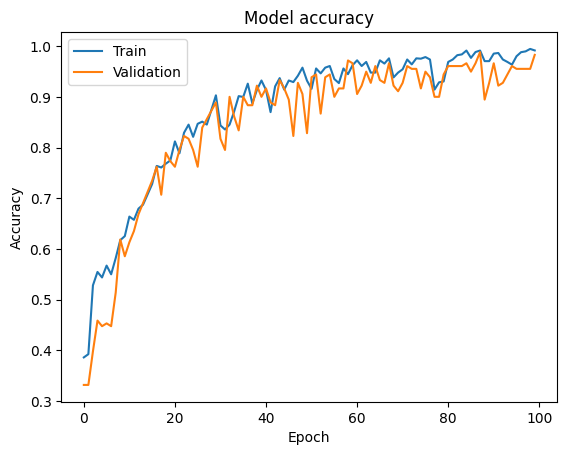

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])  # Add this line
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

scores = model.evaluate(test_generator)
print("Test Accuracy:", scores[1])

Training Accuracy: 0.9921875
Validation Accuracy: 0.9834254384040833
6/6 [==============================] - 66s 13s/step - loss: 0.3375 - accuracy: 0.9686
Test Accuracy: 0.9685863852500916


In [ ]:
scores

[0.21711203455924988, 0.9685863852500916]

In [ ]:
history

In [ ]:
history

In [ ]:
history.params

{'verbose': 1, 'epochs': 100, 'steps': 20}

In [ ]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [ ]:
class_names = list(train_generator.class_indices.keys())
class_names

['Foot and Mouth Disease',
 'Infectious Bovine Keratoconjunctivitis',
 'Lumpy Skin',
 'Normal']

In [ ]:
type(history.history['loss'])

list

In [ ]:
len(history.history['loss'])

100

In [ ]:
history.history['loss'][:5] # show loss for first 5 epochs

[1.2913035154342651,
 1.1728819608688354,
 1.1289775371551514,
 1.1319167613983154,
 1.0843204259872437]

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
val_acc

[0.33149170875549316,
 0.3867403268814087,
 0.3093922734260559,
 0.4364641010761261,
 0.4475138187408447,
 0.4419889450073242,
 0.5138121843338013,
 0.541436493396759,
 0.580110490322113,
 0.6243094205856323,
 0.6464088559150696,
 0.6740331649780273,
 0.6795580387115479,
 0.7292817831039429,
 0.6629834175109863,
 0.7458563446998596,
 0.6132596731185913,
 0.7790055274963379,
 0.8066298365592957,
 0.7845304012298584,
 0.8342541456222534,
 0.7679557800292969,
 0.7955800890922546,
 0.7624309659004211,
 0.8287292718887329,
 0.8011049628257751,
 0.8287292718887329,
 0.8784530162811279,
 0.8176795840263367,
 0.8121547102928162,
 0.8674033284187317,
 0.8674033284187317,
 0.9060773253440857,
 0.9116021990776062,
 0.9116021990776062,
 0.8950276374816895,
 0.9116021990776062,
 0.889502763748169,
 0.9281768202781677,
 0.9281768202781677,
 0.8287292718887329,
 0.8950276374816895,
 0.8950276374816895,
 0.9337016344070435,
 0.8729282021522522,
 0.9281768202781677,
 0.889502763748169,
 0.9281768202781

In [ ]:
acc

[0.36173632740974426,
 0.4437299072742462,
 0.5234375,
 0.5321543216705322,
 0.550000011920929,
 0.5659164190292358,
 0.574999988079071,
 0.610932469367981,
 0.612500011920929,
 0.672025740146637,
 0.6848874688148499,
 0.709003210067749,
 0.714062511920929,
 0.7041800618171692,
 0.7652733325958252,
 0.7282958030700684,
 0.7218649387359619,
 0.762499988079071,
 0.7829582095146179,
 0.7861736416816711,
 0.8070739507675171,
 0.8453124761581421,
 0.799035370349884,
 0.7958199381828308,
 0.827974259853363,
 0.8713826537132263,
 0.8440514206886292,
 0.86012864112854,
 0.8656250238418579,
 0.839062511920929,
 0.86012864112854,
 0.9067524075508118,
 0.9046875238418579,
 0.887499988079071,
 0.9035369753837585,
 0.934374988079071,
 0.938906729221344,
 0.9324758648872375,
 0.9046875238418579,
 0.9276527166366577,
 0.9003215432167053,
 0.90625,
 0.9421221613883972,
 0.946945309638977,
 0.9281250238418579,
 0.9340835809707642,
 0.9340835809707642,
 0.942187488079071,
 0.9581993818283081,
 0.9501608

In [ ]:
class_names = list(train_generator.class_indices.keys())
class_names

['Foot and Mouth Disease',
 'Infectious Bovine Keratoconjunctivitis',
 'Lumpy Skin',
 'Normal']

first image to predict
actual label: Normal
1/1 [==============================] - 0s 31ms/step
predicted label: Normal


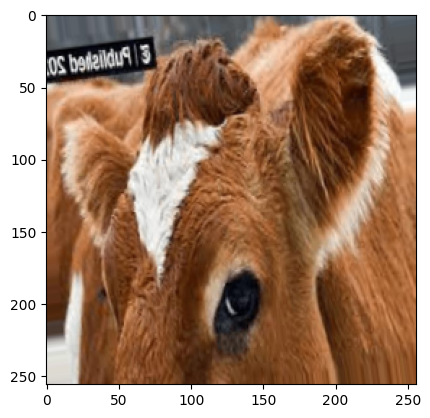

In [ ]:

import numpy as np


for image_batch, label_batch in test_generator:
    first_image = image_batch[0]
    first_label = int(label_batch[0])

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(image_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

    break

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i])
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 19ms/step


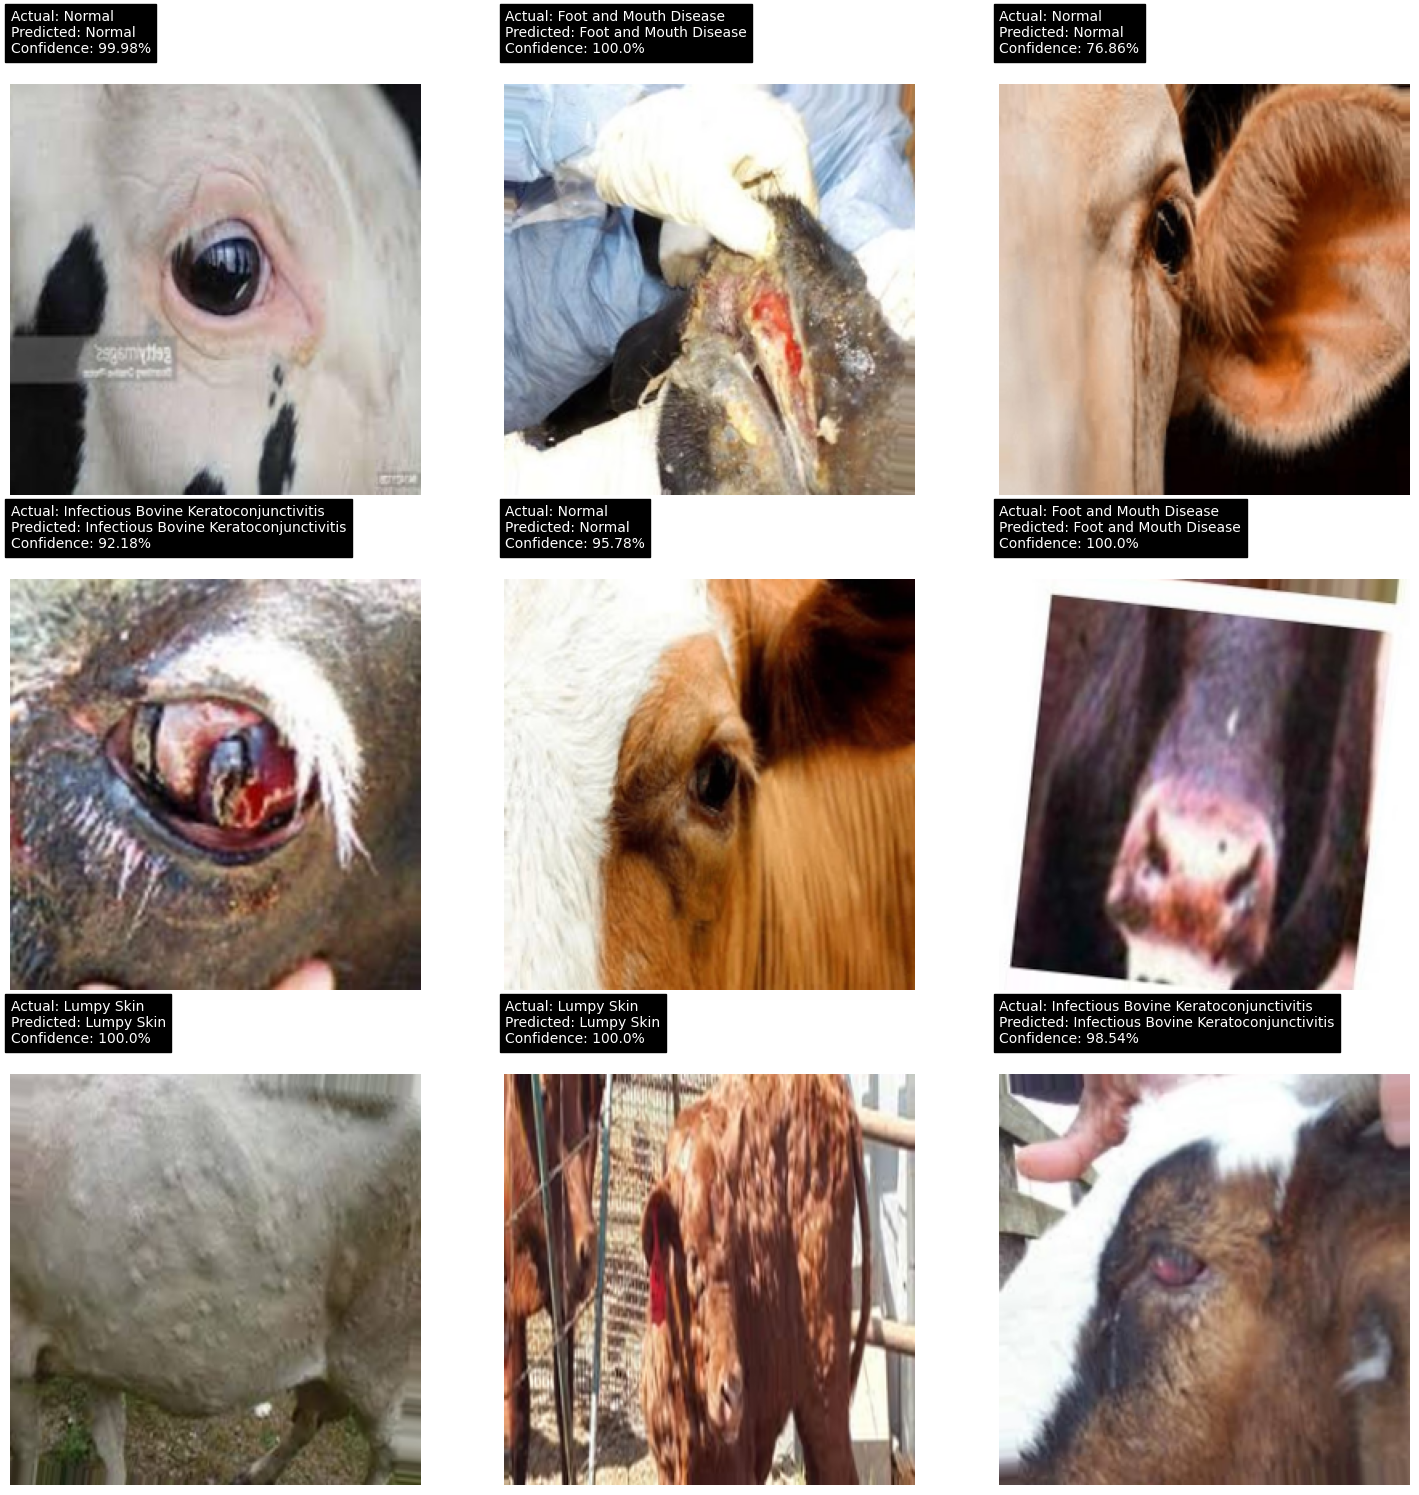

In [ ]:
plt.figure(figsize=(15, 15))

for images, labels in test_generator:
    for i in range(min(9, len(images))):  # تحقق من أن عدد الصور لا يتجاوز 9
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.axis("off")

        # قم بالتنبؤ بالصورة
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[int(labels[i])]

        # قم بإعداد النص المعلوماتي
        text = f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%"

        # إضافة النص إلى الصورة
        plt.text(0, -20, text, color='white', fontsize=10, ha='left', backgroundcolor='black')

    # اكتمل العرض للصور، فقط استمر إذا كانت هناك مزيد من الصور للعرض
    break

plt.tight_layout()  # ضبط التخطيط
plt.show()  # عرض الشكل



In [ ]:
model.save('/content/drive/MyDrive/4s.h5')